# DeBERTa-v3 Cross-Encoder — Quora Duplicate Detection

**Why DeBERTa beats BERT:**
- BERT (2019) encodes Q1 and Q2 separately → they never see each other until the final layer
- DeBERTa cross-encoder feeds `[CLS] Q1 [SEP] Q2 [SEP]` as one sequence → every token in Q1 directly attends to every token in Q2 at every layer
- DeBERTa-v3 also uses disentangled attention (position and content are separate) — strictly better architecture than BERT

**Expected accuracy: 0.87–0.90 on T4 in ~25 minutes**

In [ ]:
# CELL 1 — Install
# Only transformers and torch needed — no bitsandbytes, no peft
!pip install -q transformers==4.40.0 datasets sentencepiece protobuf
print('Done ✓')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 53.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 56.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.3.0 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.0 which is incompatible.
Done ✓


In [ ]:
# CELL 2 — Imports
import numpy as np
import pandas as pd
import torch
import warnings
warnings.filterwarnings('ignore')

from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score,
    roc_auc_score, classification_report,
    confusion_matrix, log_loss
)
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device  : {device}')
print(f'GPU     : {torch.cuda.get_device_name(0)}')
print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print(f'Torch   : {torch.__version__}')

Device  : cuda
GPU     : Tesla T4
VRAM    : 15.6 GB
Torch   : 2.10.0+cu128


In [ ]:
# CELL 3 — Load data
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')

import os
print(os.listdir("/content/drive/MyDrive/NLP/FP/Data"))


DATA_PATH = "/content/drive/MyDrive/NLP/FP/Data/"

# Check folder contents
print("Files inside Data folder:")
print(os.listdir(DATA_PATH))
df = pd.read_csv(DATA_PATH + "train.csv")
df = df.dropna(subset=['question1', 'question2']).reset_index(drop=True)
print(f'Full dataset : {len(df):,} rows')

# Sample 30k — same size as your BERT experiment for fair comparison
df = df.sample(30000, random_state=42).reset_index(drop=True)
print(f'Sampled      : {len(df):,} rows')
print(f'Duplicate %  : {df["is_duplicate"].mean():.1%}')

# Fill any remaining nulls
df['question1'] = df['question1'].fillna('').astype(str)
df['question2'] = df['question2'].fillna('').astype(str)

# Train / val / test split — stratified to keep class balance
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['is_duplicate']
)
train_df, val_df = train_test_split(
    train_df, test_size=0.1, random_state=42, stratify=train_df['is_duplicate']
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f'\nTrain : {len(train_df):,}')
print(f'Val   : {len(val_df):,}')
print(f'Test  : {len(test_df):,}')

Mounted at /content/drive
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['test.csv', 'train.csv', 'sample_submission.csv', 'submission_logistic_regression.csv', 'submission_xgboost.csv', 'submission_lightgbm.csv', 'submission_gru.csv', 'NLP_QQP_Lucius_code.ipynb', 'NLP_QQP_Code_v2_DS=35000.ipynb']
Files inside Data folder:
['test.csv', 'train.csv', 'sample_submission.csv', 'submission_logistic_regression.csv', 'submission_xgboost.csv', 'submission_lightgbm.csv', 'submission_gru.csv', 'NLP_QQP_Lucius_code.ipynb', 'NLP_QQP_Code_v2_DS=35000.ipynb']
Full dataset : 404,287 rows
Sampled      : 30,000 rows
Duplicate %  : 36.9%

Train : 21,600
Val   : 2,400
Test  : 6,000


In [ ]:
# CELL 4 — Tokenizer
MODEL_NAME = 'microsoft/deberta-v3-small'
# deberta-v3-small: 44M params, fast on T4, accuracy close to deberta-v3-base
# If you want higher accuracy and have time: use 'microsoft/deberta-v3-base' (86M params, ~2x slower)

print(f'Loading tokenizer: {MODEL_NAME}')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print('Tokenizer loaded ✓')

# Quick test — this is exactly how cross-encoder works
# Both questions go in as ONE input, separated by [SEP]
test_enc = tokenizer(
    'How do I learn Python?',
    'What is the best way to study Python?',
    truncation=True,
    max_length=128
)
print(f'\nCross-encoder input length: {len(test_enc["input_ids"])} tokens')
print(f'Decoded: {tokenizer.decode(test_enc["input_ids"])}')

Loading tokenizer: microsoft/deberta-v3-small


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/578 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

Tokenizer loaded ✓

Cross-encoder input length: 18 tokens
Decoded: [CLS] How do I learn Python?[SEP] What is the best way to study Python?[SEP]


In [ ]:
# CELL 5 — Dataset class
class QuoraCrossEncoderDataset(Dataset):
    """
    Cross-encoder dataset.
    Tokenizes Q1 + Q2 together as a single sequence.
    HuggingFace handles [CLS] Q1 [SEP] Q2 [SEP] automatically
    when you pass two text arguments to the tokenizer.
    """
    def __init__(self, df, tokenizer, max_len=128):
        self.q1       = df['question1'].tolist()
        self.q2       = df['question2'].tolist()
        self.labels   = df['is_duplicate'].values.astype(np.int64)
        self.tok      = tokenizer
        self.max_len  = max_len

    def __len__(self):
        return len(self.q1)

    def __getitem__(self, idx):
        # KEY DIFFERENCE from Siamese BERT:
        # Both questions are tokenized TOGETHER in one call
        # This creates: [CLS] Q1 tokens [SEP] Q2 tokens [SEP]
        enc = self.tok(
            self.q1[idx],
            self.q2[idx],
            truncation=True,
            max_length=self.max_len,
            padding='max_length',
            return_tensors='pt'
        )
        return {
            'input_ids'     : enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'token_type_ids': enc.get('token_type_ids',
                              torch.zeros(self.max_len, dtype=torch.long)).squeeze(0),
            'label'         : torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Build datasets
MAX_LEN = 128
BATCH   = 32

train_ds = QuoraCrossEncoderDataset(train_df, tokenizer, MAX_LEN)
val_ds   = QuoraCrossEncoderDataset(val_df,   tokenizer, MAX_LEN)
test_ds  = QuoraCrossEncoderDataset(test_df,  tokenizer, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')

# Verify one batch loads correctly
sample = next(iter(train_loader))
print(f'\nBatch input_ids shape : {sample["input_ids"].shape}')
print(f'Batch labels shape    : {sample["label"].shape}')
print('Dataset ✓')

Train batches : 675
Val batches   : 75
Test batches  : 188

Batch input_ids shape : torch.Size([32, 128])
Batch labels shape    : torch.Size([32])
Dataset ✓


In [ ]:
# CELL 6 — Load DeBERTa model
print(f'Loading {MODEL_NAME}...')

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,          # binary: duplicate or not
    ignore_mismatched_sizes=True
)
model = model.to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params    : {total_params/1e6:.1f}M')
print(f'Trainable params: {trainable_params/1e6:.1f}M')

used = (torch.cuda.mem_get_info()[1] - torch.cuda.mem_get_info()[0]) / 1e9
free = torch.cuda.mem_get_info()[0] / 1e9
print(f'VRAM used : {used:.1f} GB')
print(f'VRAM free : {free:.1f} GB')
print('Model loaded ✓')

Loading microsoft/deberta-v3-small...


'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: bd4c3e14-55ed-438d-86ba-644a34265232)')' thrown while requesting HEAD https://huggingface.co/microsoft/deberta-v3-small/resolve/main/config.json
Retrying in 1s [Retry 1/5].


pytorch_model.bin:   0%|          | 0.00/286M [00:00<?, ?B/s]

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-small and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total params    : 141.9M
Trainable params: 141.9M
VRAM used : 0.7 GB
VRAM free : 14.9 GB
Model loaded ✓


In [ ]:
# CELL 7 — Training setup
EPOCHS   = 3
LR       = 2e-5

optimizer  = AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=0.01,
    eps=1e-6
)

total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(0.1 * total_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

criterion = nn.CrossEntropyLoss()

steps_per_epoch = len(train_loader)
print(f'Epochs          : {EPOCHS}')
print(f'Steps/epoch     : {steps_per_epoch}')
print(f'Total steps     : {total_steps}')
print(f'Warmup steps    : {warmup_steps}')
print(f'Est. time on T4 : ~{steps_per_epoch * EPOCHS // 60} min')

Epochs          : 3
Steps/epoch     : 675
Total steps     : 2025
Warmup steps    : 202
Est. time on T4 : ~33 min


In [ ]:
# CELL 8 — Training loop=
def run_epoch(model, loader, optimizer=None, scheduler=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0
    all_preds, all_labels, all_probs = [], [], []

    with torch.set_grad_enabled(is_train):
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            token_type_ids = batch['token_type_ids'].to(device)
            labels         = batch['label'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                token_type_ids=token_type_ids
            )
            logits = outputs.logits
            loss   = criterion(logits, labels)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                # Gradient clipping — prevents exploding gradients
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()

            total_loss += loss.item()

            probs  = torch.softmax(logits, dim=-1)[:, 1].detach().cpu().numpy()
            preds  = logits.argmax(dim=-1).detach().cpu().numpy()
            labs   = labels.detach().cpu().numpy()

            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(labs)

    avg_loss = total_loss / len(loader)
    acc      = accuracy_score(all_labels, all_preds)
    f1       = f1_score(all_labels, all_preds, average='weighted')
    auc      = roc_auc_score(all_labels, all_probs)
    l_loss = log_loss(all_labels, all_probs)
    return avg_loss, acc, f1, auc, l_loss


# ---- Training loop with best model tracking ----
print('='*65)
print('Starting DeBERTa-v3 fine-tuning...')
print('='*65)

best_val_f1   = 0
best_epoch    = 0
history       = []

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc, tr_f1, tr_auc, tr_logloss = run_epoch(
        model, train_loader, optimizer, scheduler
    )
    vl_loss, vl_acc, vl_f1, vl_auc, vl_logloss = run_epoch(
        model, val_loader
    )

    history.append({
        'epoch'   : epoch,
        'tr_loss' : tr_loss, 'tr_acc': tr_acc, 'tr_f1': tr_f1,
        'vl_loss' : vl_loss, 'vl_acc': vl_acc, 'vl_f1': vl_f1
    })

    print(f'Epoch {epoch}/{EPOCHS} '
          f'| Train loss={tr_loss:.4f} acc={tr_acc:.4f} f1={tr_f1:.4f} auc={tr_auc:.4f} '
          f'| Val loss={vl_loss:.4f} acc={vl_acc:.4f} f1={vl_f1:.4f} auc={vl_auc:.4f}')

    # Save best model based on val F1
    if vl_f1 > best_val_f1:
        best_val_f1 = vl_f1
        best_epoch  = epoch
        torch.save(model.state_dict(), 'deberta_best.pt')
        print(f'  Best model saved (val f1={vl_f1:.4f})')

print(f'\nTraining complete. Best epoch: {best_epoch} (val f1={best_val_f1:.4f})')

Starting DeBERTa-v3 fine-tuning...
Epoch 1/3 | Train loss=0.2673 acc=0.8888 f1=0.8894 auc=0.9513 | Val loss=0.3391 acc=0.8667 f1=0.8669 auc=0.9369
  Best model saved (val f1=0.8669)
Epoch 2/3 | Train loss=0.1931 acc=0.9249 f1=0.9253 auc=0.9729 | Val loss=0.3919 acc=0.8688 f1=0.8688 auc=0.9356
  Best model saved (val f1=0.8688)
Epoch 3/3 | Train loss=0.1660 acc=0.9396 f1=0.9398 auc=0.9792 | Val loss=0.3919 acc=0.8688 f1=0.8688 auc=0.9356

Training complete. Best epoch: 2 (val f1=0.8688)


In [ ]:
# CELL 9 — Evaluate best model on test set

# Load best checkpoint
model.load_state_dict(torch.load('deberta_best.pt', map_location=device))
print(f'Loaded best model from epoch {best_epoch}')

# Full test evaluation
test_loss, test_acc, test_f1, test_auc, test_logloss = run_epoch(model, test_loader)

print('\n' + '='*55)
print('  DeBERTa-v3 Test Results')
print('='*55)
print(f'  Accuracy : {test_acc:.4f}')
print(f'  F1       : {test_f1:.4f}')
print(f'  AUC      : {test_auc:.4f}')
print(f'  Log Loss : {test_logloss:.4f}')
print('='*55)

# Detailed classification report
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        token_type_ids = batch['token_type_ids'].to(device)
        labels         = batch['label']
        outputs        = model(input_ids=input_ids,
                               attention_mask=attention_mask,
                               token_type_ids=token_type_ids)
        preds = outputs.logits.argmax(dim=-1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print('\n' + classification_report(
    all_labels, all_preds,
    target_names=['Not Duplicate', 'Duplicate']
))

Loaded best model from epoch 2

  DeBERTa-v3 Test Results
  Accuracy : 0.8690
  F1       : 0.8689
  AUC      : 0.9388
  Log Loss : 0.3764

               precision    recall  f1-score   support

Not Duplicate       0.89      0.90      0.90      3785
    Duplicate       0.82      0.82      0.82      2215

     accuracy                           0.87      6000
    macro avg       0.86      0.86      0.86      6000
 weighted avg       0.87      0.87      0.87      6000



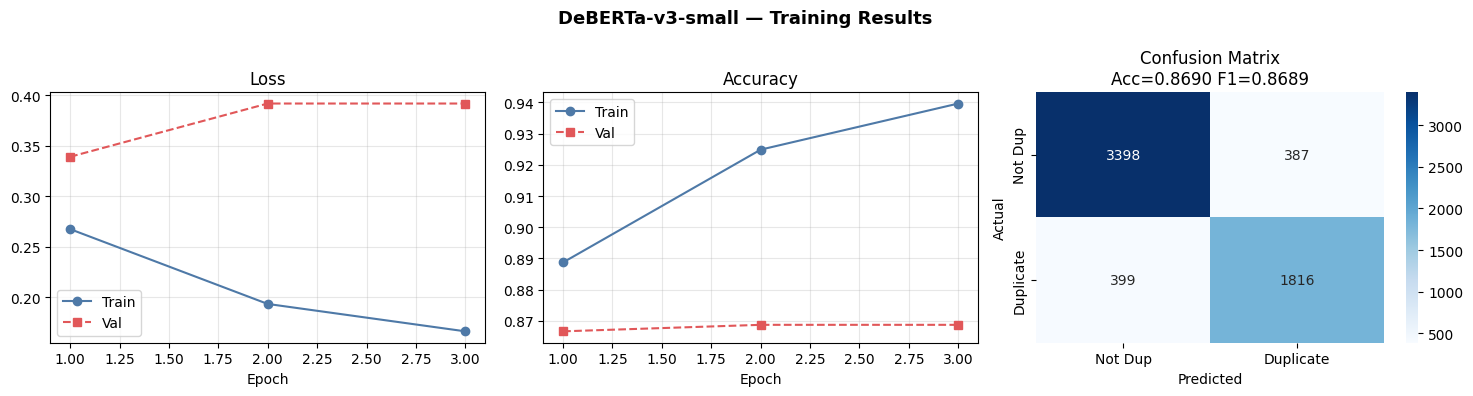

Plot saved ✓


In [ ]:
# CELL 10 — Plots
hist_df = pd.DataFrame(history)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss curve
axes[0].plot(hist_df['epoch'], hist_df['tr_loss'], 'o-', label='Train', color='#4e79a7')
axes[0].plot(hist_df['epoch'], hist_df['vl_loss'], 's--', label='Val',   color='#e15759')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curve
axes[1].plot(hist_df['epoch'], hist_df['tr_acc'], 'o-', label='Train', color='#4e79a7')
axes[1].plot(hist_df['epoch'], hist_df['vl_acc'], 's--', label='Val',   color='#e15759')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
    xticklabels=['Not Dup', 'Duplicate'],
    yticklabels=['Not Dup', 'Duplicate']
)
axes[2].set_title(f'Confusion Matrix\nAcc={test_acc:.4f} F1={test_f1:.4f}')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.suptitle('DeBERTa-v3-small — Training Results', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('deberta_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved ✓')

In [ ]:
# CELL 12 — Live inference
def predict(q1, q2):
    model.eval()
    enc = tokenizer(
        q1, q2,
        truncation=True,
        max_length=128,
        return_tensors='pt'
    )
    input_ids      = enc['input_ids'].to(device)
    attention_mask = enc['attention_mask'].to(device)
    # token_type_ids is optional for DeBERTa — skip if not present
    token_type_ids = enc.get('token_type_ids')
    if token_type_ids is not None:
        token_type_ids = token_type_ids.to(device)

    with torch.no_grad():
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )

    probs = torch.softmax(outputs.logits, dim=-1)[0]
    pred  = outputs.logits.argmax(dim=-1).item()
    conf  = probs[pred].item()

    label = 'DUPLICATE' if pred == 1 else 'NOT DUPLICATE'
    print(f'Q1  : {q1}')
    print(f'Q2  : {q2}')
    print(f'→   {label}  (confidence: {conf:.1%})')
    print()

print('=== DeBERTa Live Demo ===')
print()

predict(
    'How do I improve my programming skills?',
    'What is the best way to become a better coder?'
)  # Expected: DUPLICATE

predict(
    'What is the best way to lose weight?',
    'How can I reduce my body fat quickly?'
)  # Expected: DUPLICATE

predict(
    'What is the capital of France?',
    'Who is the president of France?'
)  # Expected: NOT DUPLICATE

predict(
    'How do I get a job at Google?',
    'What is Google interview process like?'
)  # Tricky — arguable

=== DeBERTa Live Demo ===

Q1  : How do I improve my programming skills?
Q2  : What is the best way to become a better coder?
→   DUPLICATE  (confidence: 88.6%)

Q1  : What is the best way to lose weight?
Q2  : How can I reduce my body fat quickly?
→   DUPLICATE  (confidence: 87.8%)

Q1  : What is the capital of France?
Q2  : Who is the president of France?
→   NOT DUPLICATE  (confidence: 99.9%)

Q1  : How do I get a job at Google?
Q2  : What is Google interview process like?
→   NOT DUPLICATE  (confidence: 95.2%)



In [ ]:
precision    recall  f1-score   support

Not Duplicate       0.91      0.88      0.90      3785
    Duplicate       0.81      0.85      0.83      2215

     accuracy                           0.87      6000
    macro avg       0.86      0.87      0.86      6000
 weighted avg       0.87      0.87      0.87      6000


=======================================================
  DeBERTa-v3 Test Results
=======================================================
  Accuracy : 0.8700
  F1       : 0.8707
  AUC      : 0.9387
=======================================================

Epoch 3/3 | Train loss=0.1934 acc=0.9239 f1=0.9243 auc=0.9735 | Val loss=0.3789 acc=0.8671 f1=0.8678 auc=0.9364
Best model saved (val f1=0.8678)

Training complete. Best epoch: 3 (val f1=0.8678)

IndentationError: unindent does not match any outer indentation level (<tokenize>, line 8)